# AI Customer Support Agent

## Intent Classification

### Objective

The goal of this notebook is to build the first NLP model for the project.

The model will learn to classify customer messages into one of the predefined customer support intents.

This notebook includes:

- Data preparation
- Feature selection
- Label encoding
- Text vectorization
- Model training
- Model evaluation
- Model saving

In [39]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

## Load Dataset

In [3]:
df = pd.read_csv(
    "../data/raw/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"
)

df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## Feature Selection

In [4]:
x = df["instruction"]
y = df["intent"]

In [5]:
print("First Customer Message:\n")
print(x.iloc[0])

print("\n" + "=" * 50 + "\n")

print("Corresponding Intent:\n")
print(y.iloc[0])

First Customer Message:

question about cancelling order {{Order Number}}


Corresponding Intent:

cancel_order


In [6]:
print("Number of sample" , len(x))
print("Number of labels:" , len(y))

Number of sample 26872
Number of labels: 26872


In [7]:
print("Number of Intent Classes:", y.nunique())

Number of Intent Classes: 27


## Label Encoding
Machine learning algorithms cannot work with text labels directly.

The target labels are converted into numerical values using LabelEncoder.

The encoder will later be saved so that predicted numbers can be converted back into readable intent names.

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [9]:
print("First 10 original Labels : \n ")
print(y.head(10))

print("\n" + "=" *60 + "\n")

print("First 10 Encoded Labels:\n")
print(y_encoded[:10])

First 10 original Labels : 
 
0    cancel_order
1    cancel_order
2    cancel_order
3    cancel_order
4    cancel_order
5    cancel_order
6    cancel_order
7    cancel_order
8    cancel_order
9    cancel_order
Name: intent, dtype: str


First 10 Encoded Labels:

[0 0 0 0 0 0 0 0 0 0]


In [10]:
mapping =pd.DataFrame({
    "Intent":label_encoder.classes_,
    "Encoded Value" :range(len(label_encoder.classes_))
})
mapping

,Intent,Encoded Value
0,cancel_order,0
1,change_order,1
2,change_shipping_address,2
3,check_cancellation_fee,3
4,check_invoice,4
5,check_payment_methods,5
6,check_refund_policy,6
7,complaint,7
8,contact_customer_service,8
9,contact_human_agent,9


In [11]:
mapping.to_csv(
    "../data/processed.intent_label_mapping.csv",
    index = False
)

## Train-Test Split

The dataset is divided into training and testing subsets.

- Training data is used to train the model.
- Testing data is used to evaluate the model on unseen examples.

An 80/20 split is used with stratification to preserve the class distribution.

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [14]:
print("Training Samples :", len(x_train))
print("Testing Samples  :", len(x_test))

print("\nTotal Samples    :", len(x_train) + len(x_test))

Training Samples : 21497
Testing Samples  : 5375

Total Samples    : 26872


In [15]:
print("Training Classes:", len(set(y_train)))
print("Testing Classes :", len(set(y_test)))

Training Classes: 27
Testing Classes : 27


In [17]:
train_distribution = pd.Series(y_train).value_counts().sort_index()

test_distribution = pd.Series(y_test).value_counts().sort_index()

distribution = pd.DataFrame({
    "Train": train_distribution,
    "Test": test_distribution
})

distribution

,Train,Test
0,798,200
1,798,199
2,778,195
3,760,190
4,800,200
5,799,200
6,798,199
7,800,200
8,800,200
9,799,200


## TF - IDF Vectorization
Machine learning models cannot process raw text directly.

The customer instructions are converted into numerical feature vectors using TF-IDF (Term Frequency–Inverse Document Frequency).

The vectorizer is fitted only on the training data to avoid data leakage.

In [33]:
vectorizer = TfidfVectorizer(lowercase = True,
                             stop_words = "english",
                             max_features = 5000)

In [34]:
x_train_tfidf = vectorizer.fit_transform(x_train)

x_test_tfidf = vectorizer.transform(x_test)

In [35]:
print("Training Matrix Shape :", x_train_tfidf.shape)
print("Testing Matrix Shape  :", x_test_tfidf.shape)

Training Matrix Shape : (21497, 2443)
Testing Matrix Shape  : (5375, 2443)


In [36]:
feature_name = vectorizer.get_feature_names_out()
print("First 20 features")
feature_name[:20]

First 20 features


array(['00004587345current', '00108', '00123842current', '10',
       '1200dollars', '12588', '1499dollars', '1499for', '299dollars',
       '350dollars', '370795561790current', '370795561790will', '37777',
       '732201349959current', '85632', 'aa', 'aabout', 'aailable',
       'aasistance', 'aat'], dtype=object)

In [23]:
print("Vocabulary Size: ",len(feature_name))

Vocabulary Size:  2443


## Baseline Model - Logistic Regression
A Logistic Regression classifier is trained using TF-IDF features.

This serves as the baseline model for future comparison with more advanced models such as Support Vector Machines and BERT.

In [24]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [26]:
model.fit(x_train_tfidf,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [27]:
y_pred = model.predict(x_test_tfidf)

In [29]:
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9777


In [31]:
print(classification_report(
    y_test,
    y_pred,
    target_names = label_encoder.classes_
))

                          precision    recall  f1-score   support

            cancel_order       1.00      0.96      0.98       200
            change_order       0.92      0.97      0.95       199
 change_shipping_address       0.98      0.99      0.99       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.83      0.85      0.84       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.99      0.99       200
     contact_human_agent       0.99      0.99      0.99       200
          create_account       0.99      0.96      0.97       199
          delete_account       0.93      0.99      0.96       199
        delivery_options       1.00      1.00      1.00       199
         delivery_period       1.00      0.99      1.00       200
         

In [32]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[192   7   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0]
 [  0 194   0   0   0   0   0   0   0   0   0   0   0   0   4   0   0   0
    0   1   0   0   0   0   0   0   0]
 [  0   0 194   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   1   0   0]
 [  0   0   0 190   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 170   0   0   0   0   0   0   0   0   0   0  30   0   0
    0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 200   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 198   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 200   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 198   2   0   0   0   0   0   0   0   0
    0   0   0   0   0 

In [38]:
joblib.dump(
    model,
    "../backend/app/ai/intent_model.pkl"
)

joblib.dump(
    vectorizer,
    "../backend/app/ai/tfidf_vectorizer.pkl"
)

joblib.dump(
    label_encoder,
    "../backend/app/ai/label_encoder.pkl"
)

['../backend/app/ai/label_encoder.pkl']

In [40]:
cm = confusion_matrix(y_test, y_pred)

print(cm.shape)

(27, 27)


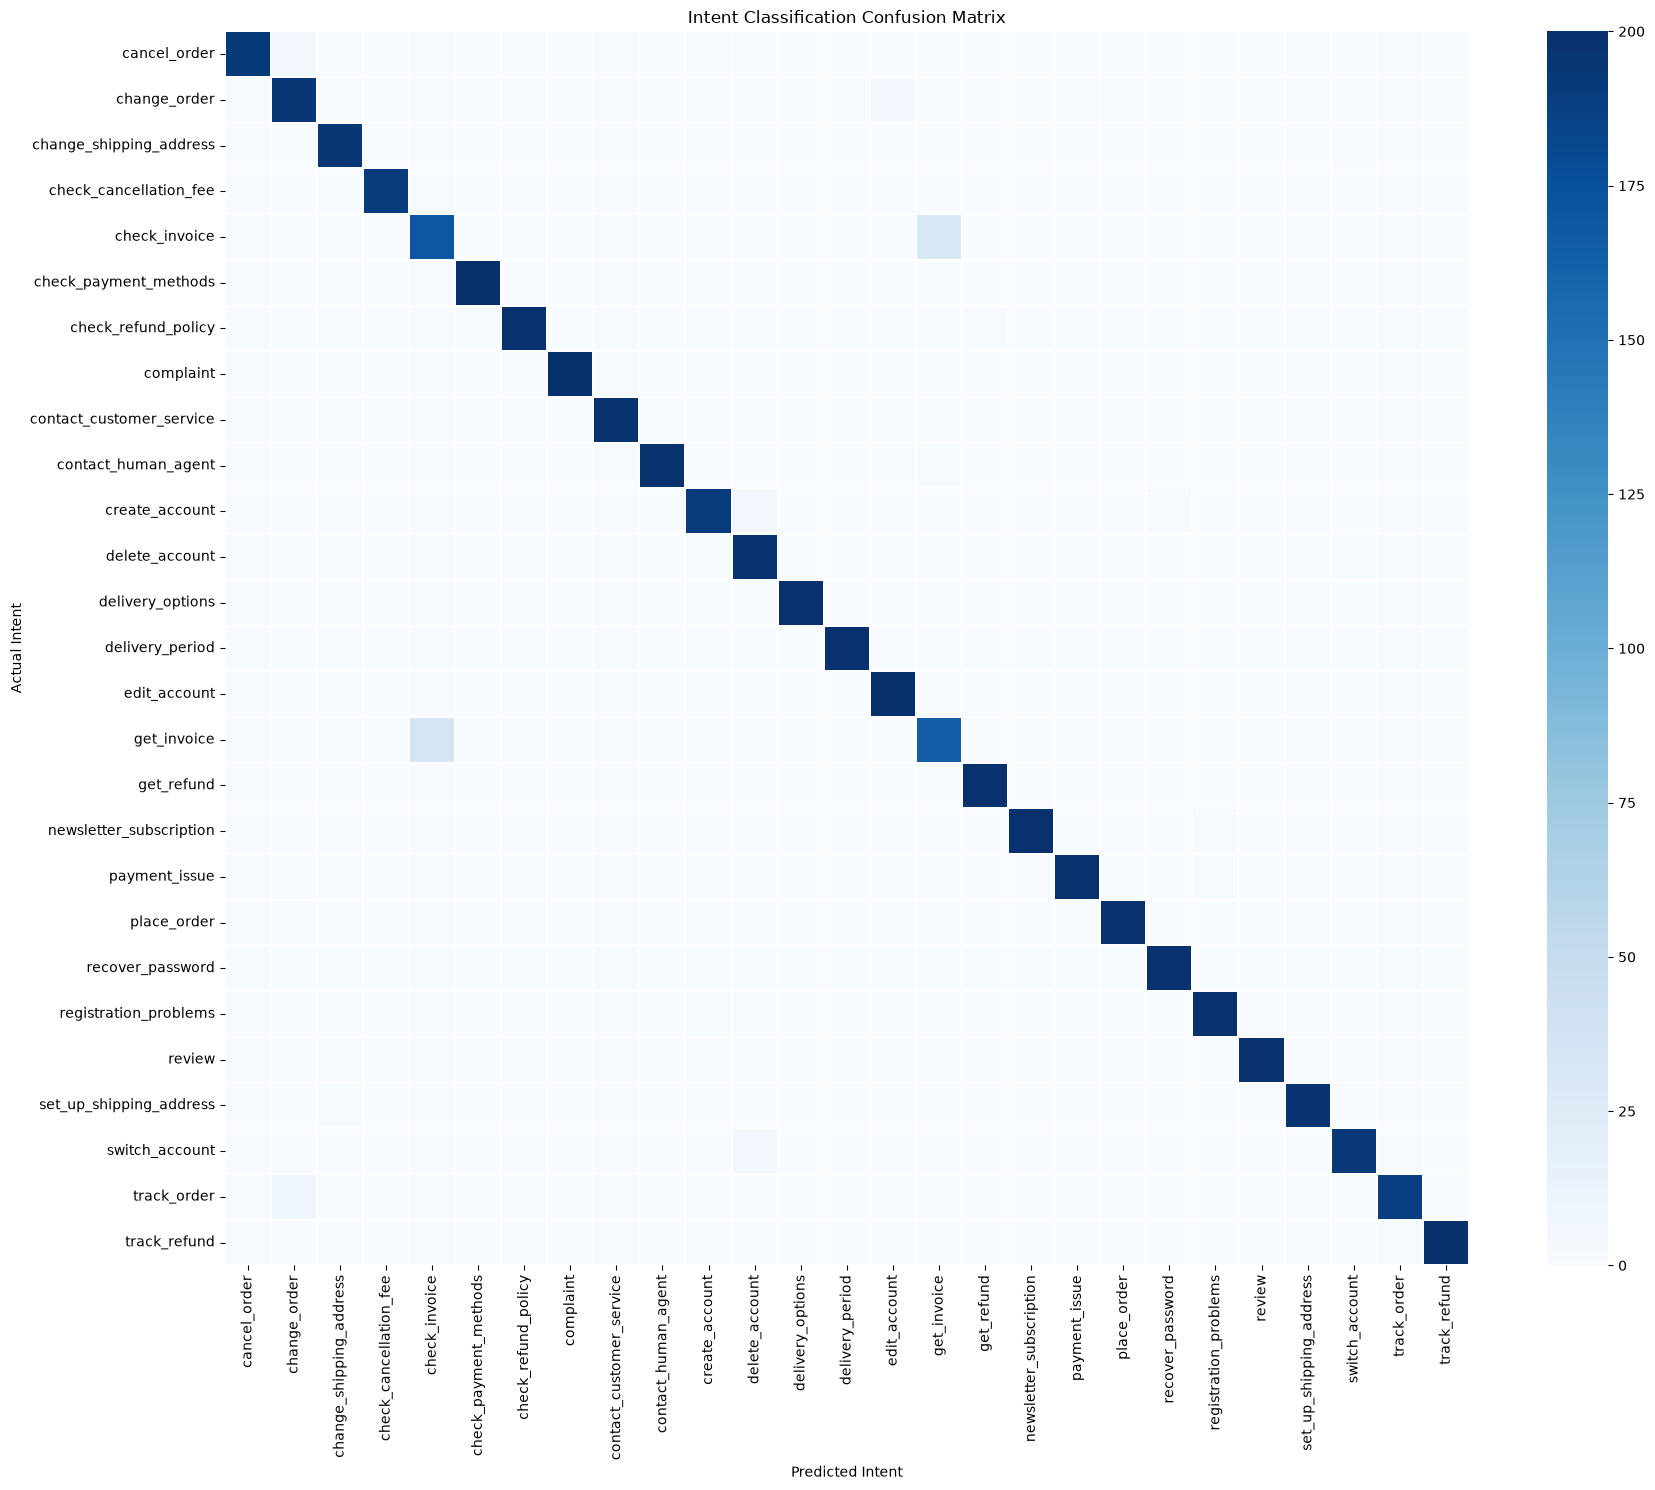

In [41]:
plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.2
)

plt.title("Intent Classification Confusion Matrix")

plt.xlabel("Predicted Intent")

plt.ylabel("Actual Intent")

plt.tight_layout()

plt.savefig(
    "../reports/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.head()

,precision,recall,f1-score,support
cancel_order,1.000000,0.960000,0.979592,200.0
change_order,0.919431,0.974874,0.946341,199.0
change_shipping_address,0.984772,0.994872,0.989796,195.0
check_cancellation_fee,1.000000,1.000000,1.000000,190.0
check_invoice,0.833333,0.850000,0.841584,200.0


In [43]:
report_df.to_csv(
    "../reports/metrics/classification_report.csv",
    index=True
)

In [44]:
lowest = report_df.sort_values(
    by="f1-score"
)

lowest.head(10)

,precision,recall,f1-score,support
get_invoice,0.837563,0.825000,0.831234,200.000000
check_invoice,0.833333,0.850000,0.841584,200.000000
change_order,0.919431,0.974874,0.946341,199.000000
delete_account,0.929245,0.989950,0.958637,199.000000
track_order,1.000000,0.949749,0.974227,199.000000
create_account,0.989637,0.959799,0.974490,199.000000
switch_account,0.984694,0.965000,0.974747,200.000000
accuracy,0.977674,0.977674,0.977674,0.977674
weighted avg,0.978064,0.977674,0.977738,5375.000000
macro avg,0.978120,0.977747,0.977803,5375.000000


In [45]:
misclassified = pd.DataFrame({
    "Instruction":x_test.reset_index(drop =True),
    "Actual":label_encoder.inverse_transform(y_test),
    "Prediction":label_encoder.inverse_transform(y_pred)
})

In [46]:
misclassified = misclassified[
    misclassified["Actual"]!=
    misclassified["Prediction"]                  
]
misclassified.head(20)

,Instruction,Actual,Prediction
33,where is order {{Order Number}}?,track_order,change_order
70,I don't know how I can find the invoices from...,check_invoice,get_invoice
79,get bills from {{Person Name}},get_invoice,check_invoice
164,I am trying to find the shipping perod,delivery_period,change_shipping_address
223,I do not know how to find invoice #85632,check_invoice,get_invoice
255,can Icontact a person?,contact_human_agent,get_invoice
270,need help canging to the premium account,switch_account,delete_account
295,wanna see bill #85632,check_invoice,get_invoice
316,see order {{Order Number}} stats,track_order,change_order
321,get bill #00108,get_invoice,check_invoice


In [47]:
misclassified.to_csv(
    "../reports/metrics/misclassified_examples.csv",
    index=False
)